# Лабораторна Робота 2
Прогнозування на основі класифікатора дерева рішень

Виконав студент Регеша Олександр КП-51мн

2026

# Завдання до лабораторної роботи 2

Потрібно створити класифікатор дерева рішень, який працюватиме з
набором даних про пасажирів, які були на борту пасажирського лайнера
«Титанік» під час його сумнозвісного рейсу.
У частині 1 потрібно створити класифікатор дерева рішень з
використанням мови програмування Python. У частині 2 потрібно застосувати
та оцінити модель дерева рішень, використовуючи відповідні технології
Python. Потрібно надати відповіді на поставлені питання у ході виконання
програмного коду та пояснити отриманий результат.

# Частина 1

## Створіть фрейм даних.

In [1]:
import pandas as pd
import urllib.request

In [4]:
training = pd.read_csv("titanic-train.csv")



training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 915 entries, 0 to 914
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  915 non-null    int64  
 1   Survived     915 non-null    int64  
 2   Pclass       915 non-null    int64  
 3   Name         915 non-null    object 
 4   Gender       915 non-null    object 
 5   Age          738 non-null    float64
 6   SibSp        915 non-null    int64  
 7   Parch        915 non-null    int64  
 8   Ticket       915 non-null    object 
 9   Fare         915 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     914 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 85.9+ KB


Чи відсутні значення у наборі даних? Скільки таких відсутніх значень?
Так, значення відсутні. З результату info() видно, що всього записів 915. У колонці Age заповнено лише 738 значень (тобто 177 відсутніх), у колонці Cabin заповнено 202 (713 відсутніх), а в колонці Embarked — 914 (1 відсутнє значення).

In [5]:
training.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,1,"Davidson, Mr. Thornton",male,31.0,1,0,F.C. 12750,52.0000,B71,S
1,2,0,3,"Asim, Mr. Adola",male,35.0,0,0,SOTON/O.Q. 3101310,7.0500,NaN,S
2,3,0,3,"Nankoff, Mr. Minko",male,NaN,0,0,349218,7.8958,NaN,S
3,4,0,1,"Thayer, Mr. John Borland",male,49.0,1,1,17421,110.8833,C68,C
4,5,0,3,"Strandberg, Miss. Ida Sofia",female,22.0,0,0,7553,9.8375,NaN,S


## Підготуйте дані для побудови моделі.

In [6]:
training["Gender"] = training["Gender"].apply(lambda toLabel: 0 if toLabel == 'male' else 1)

training.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,1,"Davidson, Mr. Thornton",0,31.0,1,0,F.C. 12750,52.0000,B71,S
1,2,0,3,"Asim, Mr. Adola",0,35.0,0,0,SOTON/O.Q. 3101310,7.0500,NaN,S
2,3,0,3,"Nankoff, Mr. Minko",0,NaN,0,0,349218,7.8958,NaN,S
3,4,0,1,"Thayer, Mr. John Borland",0,49.0,1,1,17421,110.8833,C68,C
4,5,0,3,"Strandberg, Miss. Ida Sofia",1,22.0,0,0,7553,9.8375,NaN,S


In [7]:
mean_age = training["Age"].mean()
training["Age"].fillna(mean_age, inplace=True)

/tmp/ipykernel_719/609142997.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  training["Age"].fillna(mean_age, inplace=True)


In [8]:
print("Кількість порожніх значень Age:", training["Age"].isna().sum())
print("Середній вік, яким замінили пропуски:", mean_age)

Кількість порожніх значень Age: 0
Середній вік, яким замінили пропуски: 29.970867208672086


In [10]:
training.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,1,"Davidson, Mr. Thornton",0,31.000000,1,0,F.C. 12750,52.0000,B71,S
1,2,0,3,"Asim, Mr. Adola",0,35.000000,0,0,SOTON/O.Q. 3101310,7.0500,NaN,S
2,3,0,3,"Nankoff, Mr. Minko",0,29.970867,0,0,349218,7.8958,NaN,S
3,4,0,1,"Thayer, Mr. John Borland",0,49.000000,1,1,17421,110.8833,C68,C
4,5,0,3,"Strandberg, Miss. Ida Sofia",1,22.000000,0,0,7553,9.8375,NaN,S


Наведіть число відсутніх значень для атрибуту віку: Було 177 відсутніх значень.
Яке значення було використано для заміни відсутніх значень віку? Для заміни було використано середнє значення віку по всьому датасету: приблизно 29.97 років. Зміну можна побачити у пасажира з id = 3.

## Навчіть і оцініть модель класифікатора дерева рішень.

In [11]:
y_target = training["Survived"].values


columns = ["Fare", "Pclass", "Gender", "Age", "SibSp"]
X_input = training[list(columns)].values


from sklearn import tree

clf_train = tree.DecisionTreeClassifier(criterion="entropy", max_depth=3)
clf_train = clf_train.fit(X_input, y_target)


accuracy = clf_train.score(X_input, y_target)
print(f"Точність моделі: {accuracy * 100:.2f}%")

Точність моделі: 81.64%


## Візуалізуйте дерево рішень.

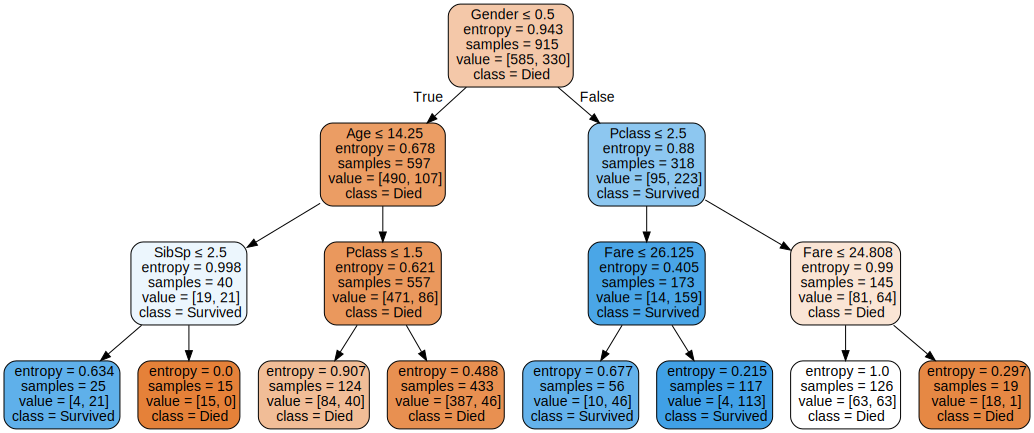

In [12]:
import graphviz

dot_data = tree.export_graphviz(clf_train, out_file=None,
                                feature_names=columns,
                                class_names=['Died', 'Survived'],
                                filled=True, rounded=True,
                                special_characters=True)

graph = graphviz.Source(dot_data)
graph

Виходячи з даних кореневого вузла, скільки спостережень складають набір навчальних даних?
Кореневий вузол показує, що набір навчальних даних складається з 915 спостережень (samples = 915).

Виходячи з даних наступного рівня, скільки пасажирів були чоловіками, а скільки жінками?
Умова в корені Gender <= 0.5 ділить пасажирів за статтю. Зліва (умова True, тобто чоловіки, бо у них значення 0) — 597 пасажирів. Справа (умова False, тобто жінки, бо у них значення 1) — 318 пасажирів.

Виходячи з даних кореневого вузла, скільки людей з даної вибірки померли та скільки вижили?
У кореневому вузлі є масив value = [585, 330]. Це означає, що загалом 585 людей померли, а 330 — вижили.

Що характеризує групу, яка мала найбільше смертей за кількістю?
Найбільша кількість смертей (387 загиблих) зафіксована у групі дорослих чоловіків (старших за 14.25 років), які подорожували нижчими класами (2-й та 3-й клас, умова Pclass > 1.5).

У якій групі вижило найбільше пасажирів?
Найбільше пасажирів вижило (113 осіб зі 117 у вузлі) у групі жінок, які подорожували 1-м або 2-м класом (Pclass <= 2.5) і заплатили за квиток більше ніж 26.125 фунтів (Fare > 26.125).

# Частина 2

## Імпортуйте та підготуйте дані.

In [16]:
import pandas as pd
import urllib.request

testing = pd.read_csv("titanic-test.csv")

testing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  393 non-null    int64  
 1   Survived     393 non-null    int64  
 2   Pclass       393 non-null    int64  
 3   Name         393 non-null    object 
 4   Gender       393 non-null    object 
 5   Age          307 non-null    float64
 6   SibSp        393 non-null    int64  
 7   Parch        393 non-null    int64  
 8   Ticket       393 non-null    object 
 9   Fare         393 non-null    float64
 10  Cabin        93 non-null     object 
 11  Embarked     392 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 37.0+ KB


Скільки записів у наборі даних?
У наборі даних тестування 393 записи (від 0 до 392).

Яких важливих змінних значень немає, скільки відсутніх?
Змінні з відсутніми (порожніми) значеннями:

Age (вік) — відсутні 86 значень (заповнено 307 із 393).

Cabin (каюта) — відсутні 300 значень (заповнено лише 93 із 393).

Embarked (порт посадки) — відсутнє 1 значення (заповнено 392 із 393).

In [17]:
testing.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,916,0,2,"Coleridge, Mr. Reginald Charles",male,29.0,0,0,W./C. 14263,10.50,NaN,S
1,917,1,1,"Spedden, Mrs. Frederic Oakley (Margaretta Corn...",female,40.0,1,1,16966,134.50,E34,C
2,918,0,3,"Windelov, Mr. Einar",male,21.0,0,0,SOTON/OQ 3101317,7.25,NaN,S
3,919,1,1,"Minahan, Miss. Daisy E",female,33.0,1,0,19928,90.00,C78,Q
4,920,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.00,NaN,S


In [18]:
testing["Gender"] = testing["Gender"].apply(lambda toLabel: 0 if toLabel == 'male' else 1)

testing["Age"].fillna(testing["Age"].mean(), inplace=True)

testing.info()
testing.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 393 entries, 0 to 392
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  393 non-null    int64  
 1   Survived     393 non-null    int64  
 2   Pclass       393 non-null    int64  
 3   Name         393 non-null    object 
 4   Gender       393 non-null    int64  
 5   Age          393 non-null    float64
 6   SibSp        393 non-null    int64  
 7   Parch        393 non-null    int64  
 8   Ticket       393 non-null    object 
 9   Fare         393 non-null    float64
 10  Cabin        93 non-null     object 
 11  Embarked     392 non-null    object 
dtypes: float64(2), int64(6), object(4)
memory usage: 37.0+ KB


/tmp/ipykernel_719/2669297897.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  testing["Age"].fillna(testing["Age"].mean(), inplace=True)


,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,916,0,2,"Coleridge, Mr. Reginald Charles",0,29.0,0,0,W./C. 14263,10.50,NaN,S
1,917,1,1,"Spedden, Mrs. Frederic Oakley (Margaretta Corn...",1,40.0,1,1,16966,134.50,E34,C
2,918,0,3,"Windelov, Mr. Einar",0,21.0,0,0,SOTON/OQ 3101317,7.25,NaN,S
3,919,1,1,"Minahan, Miss. Daisy E",1,33.0,1,0,19928,90.00,C78,Q
4,920,1,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.00,NaN,S


Значення умпішно замінено

## Позначте набір даних тестування.

In [19]:
columns = ["Fare", "Pclass", "Gender", "Age", "SibSp"]

X_input = testing[list(columns)].values

target_labels = clf_train.predict(X_input)

target_labels_df = pd.DataFrame({'Est_Survival': target_labels, 'Name': testing['Name']})

target_labels_df.head()

,Est_Survival,Name
0,0,"Coleridge, Mr. Reginald Charles"
1,1,"Spedden, Mrs. Frederic Oakley (Margaretta Corn..."
2,0,"Windelov, Mr. Einar"
3,1,"Minahan, Miss. Daisy E"
4,0,"Wilkes, Mrs. James (Ellen Needs)"


In [21]:
import numpy as np

all_data = pd.read_csv("titanic_all.csv")

testing_results = pd.merge(target_labels_df, all_data[['Name','Survived']], on=['Name'])

acc = np.sum(testing_results['Est_Survival'] == testing_results['Survived']) / float(len(testing_results))

print(f"Точність на тестовій вибірці: {acc * 100:.2f}%")

Точність на тестовій вибірці: 75.89%


## Імпортуйте дані.

In [28]:
all_data = pd.read_csv("titanic_all.csv", usecols=['Survived','Pclass','Gender','Age','SibSp','Fare'])
all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1308 entries, 0 to 1307
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  1308 non-null   int64  
 1   Pclass    1308 non-null   int64  
 2   Gender    1308 non-null   object 
 3   Age       1045 non-null   float64
 4   SibSp     1308 non-null   int64  
 5   Fare      1308 non-null   float64
dtypes: float64(2), int64(3), object(1)
memory usage: 61.4+ KB


Скільки записів у наборі даних?
У наборі даних all_data міститься 1308 записів (індекси від 0 до 1307).

Яких важливих значень змінних немає, скільки всього відсутніх значень?
Серед вибраних змінних відсутні (порожні) значення є лише в колонці Age (вік). Із 1308 записів заповнено 1045, отже, відсутні 263 значення (1308 - 1045 = 263). Усі інші колонки (Survived, Pclass, Gender, SibSp, Fare) заповнені повністю.

In [29]:
all_data.head()

,Survived,Pclass,Gender,Age,SibSp,Fare
0,1,1,female,29.0000,0,211.3375
1,1,1,male,0.9167,1,151.5500
2,0,1,female,2.0000,1,151.5500
3,0,1,male,30.0000,1,151.5500
4,0,1,female,25.0000,1,151.5500


## Підготуйте дані.

In [35]:
all_data["Gender"] = all_data["Gender"].apply(lambda toLabel: 0 if toLabel == 'male' else 1)
age = all_data["Age"].mean()
all_data["Age"].fillna(age, inplace=True)
print("Середній вік, яким замінили пропуски:", age)
print("Кількість порожніх значень Age:", training["Age"].isna().sum())
all_data.head()

Середній вік, яким замінили пропуски: 29.851834162679427
Кількість порожніх значень Age: 0


/tmp/ipykernel_719/98072561.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  all_data["Age"].fillna(age, inplace=True)


,Survived,Pclass,Gender,Age,SibSp,Fare
0,1,1,1,29.0000,0,211.3375
1,1,1,1,0.9167,1,151.5500
2,0,1,1,2.0000,1,151.5500
3,0,1,1,30.0000,1,151.5500
4,0,1,1,25.0000,1,151.5500


## Створіть вхідні та вихідні змінні для даних навчання та тестування.

In [36]:
from sklearn.model_selection import train_test_split

columns = ["Fare", "Pclass", "Gender", "Age", "SibSp"]
X = all_data[list(columns)].values
y = all_data["Survived"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.40, random_state=0)

from sklearn import tree

clf_train = tree.DecisionTreeClassifier(criterion="entropy", max_depth=3)

clf_train = clf_train.fit(X_train, y_train)

train_score = str(clf_train.score(X_train, y_train))
test_score = str(clf_train.score(X_test, y_test))

print('Training score = ' + train_score + ' Testing score = ' + test_score)

Training score = 0.7104591836734694 Testing score = 0.6851145038167938


Який результат ви отримали?
Ми отримали такі результати точності нашої моделі дерева рішень:

Training score (точність на навчальних даних): приблизно 0.71 (або 71%).

Testing score (точність на тестових даних): приблизно 0.685 (або 68.5%).

Порівняйте оцінки для навченої моделі як за тестовими, так і з валідаційними (перевірочними) даними.
Оцінка точності на тестових даних (68.5%) є досить близькою, але трохи нижчою, ніж оцінка на навчальних даних (71%). Це цілком закономірний і нормальний результат.

Модель завжди показує кращий результат на тих даних, які вона вже «бачила» під час навчання. Проте саме оцінка на тестовому наборі (Testing score) є справжнім показником того, наскільки добре модель здатна узагальнювати інформацію та робити прогнози для абсолютно нових пасажирів.

Оскільки різниця між оцінками невелика (лише близько 2.5%), ми можемо зробити висновок, що модель не перенавчилася. Проте загальна точність у 68-71% свідчить про те, що для кращого прогнозування виживаності нам могло б знадобитися більше даних, зміна параметрів дерева або використання більш складних алгоритмів.

# Висновки до лабораторної роботи:
У ході виконання лабораторної роботи ми на практиці ознайомилися з алгоритмом машинного навчання з учителем (Supervised learning) — класифікацією за допомогою дерев рішень. На прикладі даних пасажирів «Титаніка» ми навчилися:

Здійснювати попередню обробку даних за допомогою pandas (заповнення пропущених значень віку, перетворення категоріальної змінної статі на числові мітки).

Будувати та навчати модель DecisionTreeClassifier з бібліотеки scikit-learn.

Візуалізувати та інтерпретувати побудоване дерево, визначаючи ключові фактори, що вплинули на виживання (стать, клас квитка, вік).

Оцінювати якість моделі, розбиваючи дані на навчальну та тестову вибірки (train_test_split), що дозволило перевірити здатність алгоритму до узагальнення та переконатися у відсутності перенавчання (overfitting).

# Питання для самоперевірки
1. Дайте визначення методу дерев рішень (decision trees). Для чого він використовується?

Дерево рішень — це алгоритм машинного навчання, який моделює процес прийняття рішень у вигляді деревоподібної структури, де кожен внутрішній вузол перевіряє певну умову (атрибут), кожна гілка є результатом перевірки, а кожен лист — кінцевим прогнозом (класом або значенням). Використовується для задач класифікації (вижив/загинув, хворий/здоровий) та регресії (прогнозування ціни).

2. Як будуються та використовуються бінарні дерева? Наведіть приклад.

У бінарному дереві кожен вузол завжди розгалужується рівно на дві гілки (так/ні, True/False). Алгоритм шукає умову, яка найкраще розділяє дані на дві максимально однорідні групи, і так повторюється рекурсивно.
Приклад з нашої лаби: Вузол перевіряє Gender <= 0.5 (чи є пасажир чоловіком?). Якщо True (так) — йдемо вліво, якщо False (ні, жінка) — йдемо вправо.

3. Які існують переваги методу дерева рішень?

Зрозумілість та прозорість: Дерева легко візуалізувати та пояснити людині (це модель "білого ящика").

Мінімум підготовки даних: Не вимагають стандартизації або нормалізації (як це було потрібно для K-Means).

Універсальність: Можуть працювати як з числовими (вік, ціна), так і з категоріальними даними.

4. Які існують критерії розщеплення дерева рішень?
Алгоритм використовує математичні метрики, щоб зрозуміти, яка умова найкраще розділить дані:

Ентропія (Entropy / Information Gain): Вимірює рівень хаосу або невизначеності у вузлі (саме її ми використовували в коді criterion="entropy").

Критерій Джині (Gini Impurity): Вимірює ймовірність того, що випадковий елемент буде неправильно класифікований. Працює трохи швидше за ентропію.

5. Які існують варіанти зупинки навчання дерева рішень?
Щоб дерево не розрослося до кожного окремого пасажира (що призведе до перенавчання), використовують критерії зупинки:

Обмеження максимальної глибини дерева (max_depth).

Мінімальна кількість зразків, необхідна для створення нового розгалуження (min_samples_split).

Досягнення "чистого" вузла (ентропія = 0), де всі елементи належать до одного класу.

6. Які інструменти Python використовуються для побудови дерева рішень?

pandas — для підготовки даних (читання, обробка пропусків).

scikit-learn (sklearn.tree) — для безпосереднього створення, навчання (DecisionTreeClassifier) та оцінки моделі.

graphviz або інструменти sklearn.tree.export_graphviz — для малювання графічної структури дерева.

7. Як реалізовується оцінка моделі класифікатора дерева рішень?
Оцінка реалізовується шляхом розділення вихідного набору даних на дві частини: навчальну і тестову (за допомогою train_test_split). Модель тренується лише на навчальній вибірці (метод .fit()), а потім перевіряє свої прогнози на тестовій (метод .score()). Порівняння точності (accuracy) на обох вибірках дозволяє об'єктивно оцінити якість моделі.